<a href="https://colab.research.google.com/github/naman065/Machine-Learning/blob/main/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CLASH OF T-AI-TANS**
## PLANT DISEASE DETECTION MODEL##


In [16]:
!git clone https://github.com/pratikkayal/PlantDoc-Dataset.git



Cloning into 'PlantDoc-Dataset'...
remote: Enumerating objects: 2670, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 2670 (delta 23), reused 40 (delta 22), pack-reused 2628
Receiving objects: 100% (2670/2670), 932.92 MiB | 32.42 MiB/s, done.
Resolving deltas: 100% (24/24), done.
Updating files: 100% (2581/2581), done.


*Thanks to Pratik Kayal for the Dataset Of Plant Leaf Images*
https://github.com/pratikkayal/PlantDoc-Dataset.git


In [17]:
import os

os.chdir('/content/PlantDoc-Dataset')
os.listdir('/content/PlantDoc-Dataset')


['logs',
 'results',
 'PlantDoc_Examples.png',
 'LICENSE.txt',
 'PlantDoc-Dataset',
 'train',
 '.git',
 'README.md',
 'test']

# Installing Necessary Libraries For Image Classification Model

In [18]:
# Installing necessary libraries
!pip install tensorflow transformers

# Importing libraries
import tensorflow as tf
from transformers import ViTForImageClassification, ViTFeatureExtractor
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import classification_report, confusion_matrix


# Image Preprocessing and Data Augmentation

In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import os
import shutil


train_dir = '/content/PlantDoc-Dataset/train'
class_to_remove = 'Tomato two spotted spider mites leaf'

class_dir_to_remove = os.path.join(train_dir, class_to_remove)
if os.path.exists(class_dir_to_remove):
    shutil.rmtree(class_dir_to_remove)
    print(f'Removed class directory: {class_to_remove}')
else:
    print(f'Class directory not found: {class_to_remove}')


test_dir = '/content/PlantDoc-Dataset/test'

# Creating an ImageDataGenerator for data augmentation and normalization
train_datagen = ImageDataGenerator(rescale=1.0/255,   # Normalize pixel values to [0, 1]
                                   rotation_range=20, # Randomly rotate images
                                   width_shift_range=0.2, # Randomly shift images horizontally
                                   height_shift_range=0.2, # Randomly shift images vertically
                                   shear_range=0.2, # Randomly shear images
                                   zoom_range=0.2, # Randomly zoom images
                                   horizontal_flip=True, # Randomly flip images horizontally
                                   fill_mode='nearest') # Fill missing pixels after transformations

# Loading the training data
train_generator = train_datagen.flow_from_directory(train_dir,
                                                    target_size=(224, 224),
                                                    batch_size=32,
                                                    class_mode='categorical') # Using 'categorical' for multi-class classification

# Creating a test ImageDataGenerator (only rescaling, no augmentation)
test_datagen = ImageDataGenerator(rescale=1.0/255)

test_generator = test_datagen.flow_from_directory(test_dir,
                                                  target_size=(224, 224),
                                                  batch_size=32,
                                                  class_mode='categorical',
                                                  shuffle=False) # Do not shuffle test data


Class directory not found: Tomato two spotted spider mites leaf
Found 2340 images belonging to 27 classes.
Found 236 images belonging to 27 classes.


##Using a Pre Trained Model **EfficientNetB0** and fine tuning the model by adding custom layers for our problem

In [20]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)


x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
outputs = tf.keras.layers.Dense(train_generator.num_classes, activation='softmax')(x)


model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

# Compiling the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Training the model
history = model.fit(train_generator,
                    validation_data=test_generator,
                    epochs=10)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


74/74 ━━━━━━━━━━━━━━━━━━━━ 947s 11s/step - accuracy: 0.1081 - loss: 3.2026 - val_accuracy: 0.0466 - val_loss: 3.2942
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 878s 12s/step - accuracy: 0.3534 - loss: 2.4346 - val_accuracy: 0.0466 - val_loss: 3.2970
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 846s 11s/step - accuracy: 0.5351 - loss: 1.6889 - val_accuracy: 0.0551 - val_loss: 3.2966
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 890s 12s/step - accuracy: 0.6410 - loss: 1.2661 - val_accuracy: 0.0424 - val_loss: 3.2941
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 892s 11s/step - accuracy: 0.7104 - loss: 1.0060 - val_accuracy: 0.0763 - val_loss: 3.2703
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 861s 11s/step - accuracy: 0.7602 - loss: 0.8242 - val_accuracy: 0.2161 - val_loss: 2.9244
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 872s 11s/step - accuracy: 0.7982 - loss: 0.6828 - val_accuracy: 0.2924 - val_loss: 2.4981
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 841s 11s/step - accuracy: 0.8273 - loss: 0.5504 - val_accuracy: 0.3814 - val_

# Evaluating the model on validation data and making a confusion matrix for evaluating performance of the model!

8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5012 - loss: 1.6455
Validation Accuracy: 50.42%
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step
                            precision    recall  f1-score   support

           Apple Scab Leaf       0.78      0.70      0.74        10
                Apple leaf       0.38      0.67      0.48         9
           Apple rust leaf       0.80      0.40      0.53        10
          Bell_pepper leaf       0.50      0.12      0.20         8
     Bell_pepper leaf spot       0.45      0.56      0.50         9
            Blueberry leaf       0.50      0.18      0.27        11
               Cherry leaf       0.47      0.70      0.56        10
       Corn Gray leaf spot       0.33      0.50      0.40         4
          Corn leaf blight       0.56      0.75      0.64        12
            Corn rust leaf       0.80      0.80      0.80        10
                Peach leaf       0.60      0.33      0.43         9
  Potato leaf early blight       0.25      0.25

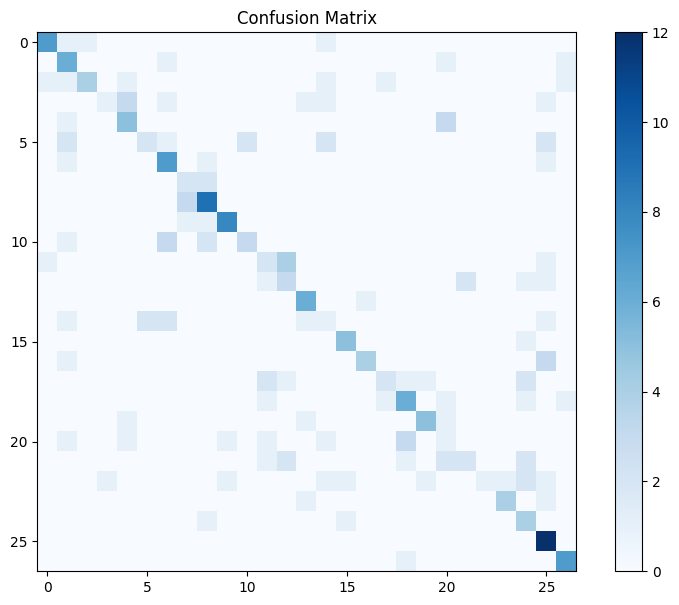

In [31]:

val_loss, val_acc = model.evaluate(test_generator)
print(f'Validation Accuracy: {(val_acc) * 100:.2f}%')


y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=-1)
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 7))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()
plt.show()





In [24]:
model_save_path = '/content/drive/My Drive/plant_disease_vit_model.h5'
model.save(model_save_path)

# GRADIO INTERFACE FOR THE MODEL

In [26]:


import gradio as gr
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image


model = tf.keras.models.load_model('/content/drive/MyDrive/plant_disease_vit_model.h5')


class_names = [
    'Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf',
    'Bell_pepper leaf spot', 'Bell_pepper leaf', 'Blueberry leaf',
    'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight',
    'Corn rust leaf', 'Peach leaf', 'Potato leaf early blight',
    'Potato leaf late blight', 'Raspberry leaf', 'Soyabean leaf',
    'Squash Powdery mildew leaf', 'Strawberry leaf', 'Tomato Early blight leaf',
    'Tomato Septoria leaf spot', 'Tomato leaf bacterial spot',
    'Tomato leaf late blight', 'Tomato leaf mosaic virus',
    'Tomato leaf yellow virus', 'Tomato leaf', 'Tomato mold leaf',
    'grape leaf black rot', 'grape leaf'
]


def predict_disease(img):

    img = img.resize((224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0


    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    return class_names[predicted_class]


interface = gr.Interface(
    fn=predict_disease,
    inputs=gr.Image(type="pil", label="Upload Plant Leaf Image"),
    outputs=gr.Textbox(label="Predicted Disease Class"),
    live=True
)
interface.launch()


Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://aa272b25df803af22f.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)
